
Processing model: w2v
✔ Parcel average saved: /home/y-sato/venv/kenkyu1/analysis_corr/w2v_bronx_parcel_mean_scaled_corr.csv
✔ Subject average saved: /home/y-sato/venv/kenkyu1/analysis_corr/w2v_bronx_subject_mean_corr.csv

=== Mean correlations for this model ===
pred_vs_group: -0.0029
subj_vs_group: 0.2602
pred_vs_actual: 0.0010
pred_vs_other_story: -0.0373
pred_vs_other_story_group: -0.0407


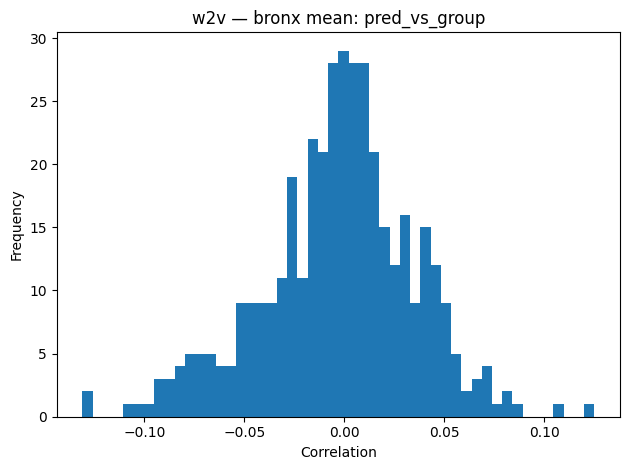

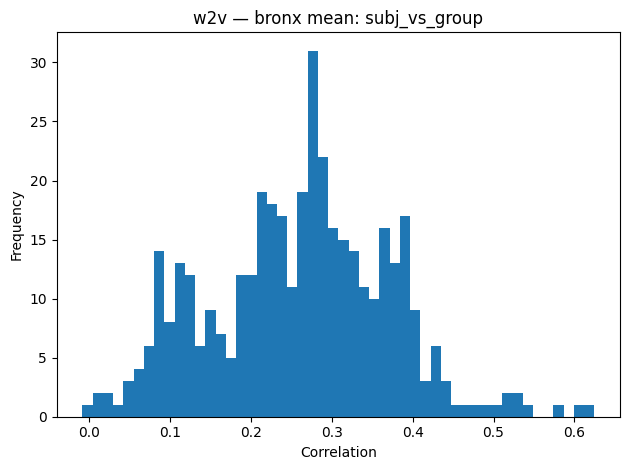

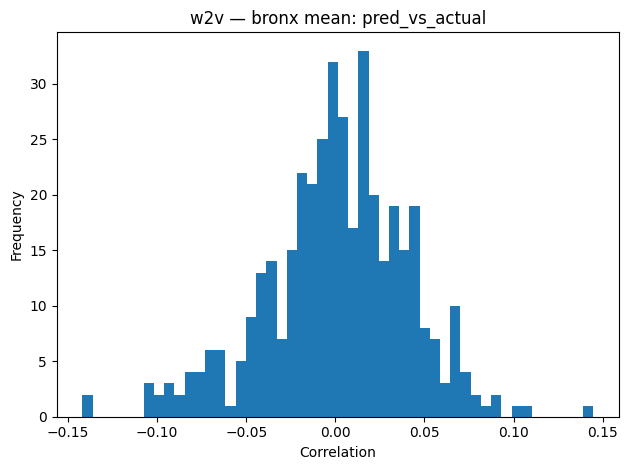

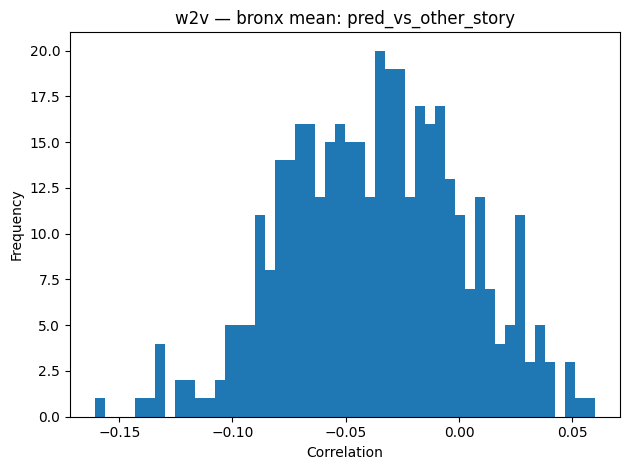

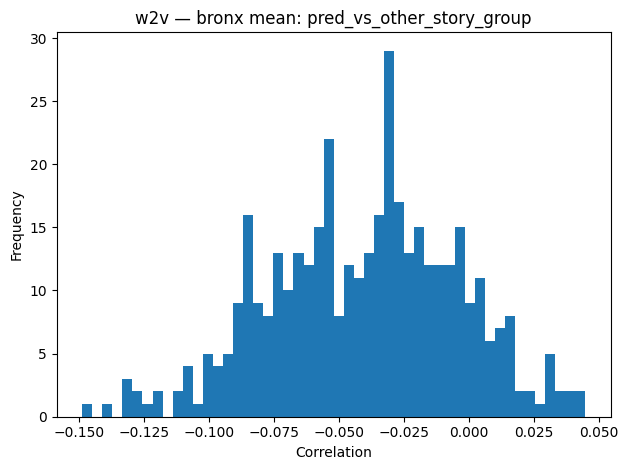


Processing model: llama
✔ Parcel average saved: /home/y-sato/venv/kenkyu1/analysis_corr/llama_bronx_parcel_mean_scaled_corr.csv
✔ Subject average saved: /home/y-sato/venv/kenkyu1/analysis_corr/llama_bronx_subject_mean_corr.csv

=== Mean correlations for this model ===
pred_vs_group: -0.0151
subj_vs_group: 0.2602
pred_vs_actual: -0.0172
pred_vs_other_story: -0.0238
pred_vs_other_story_group: -0.0295


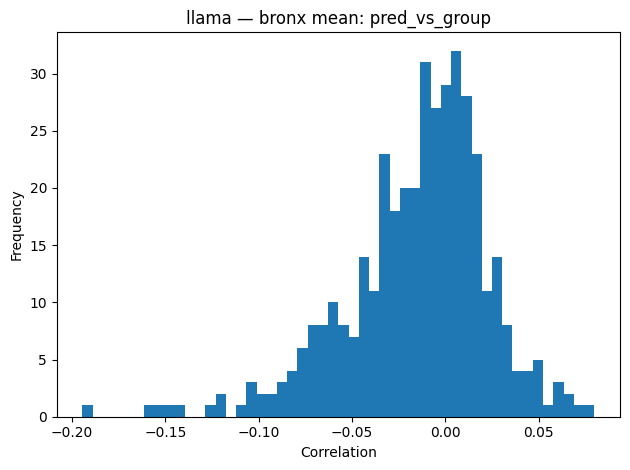

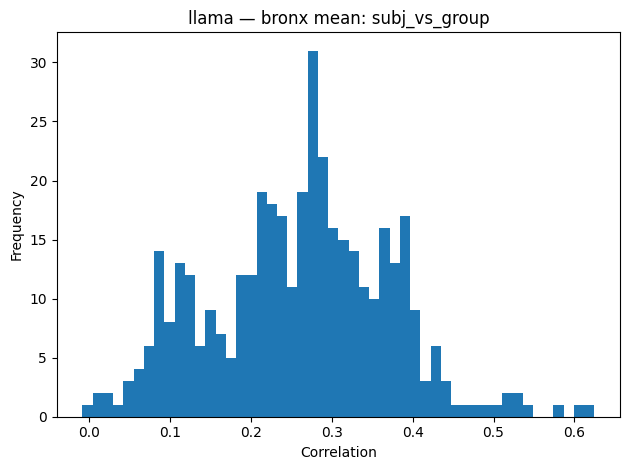

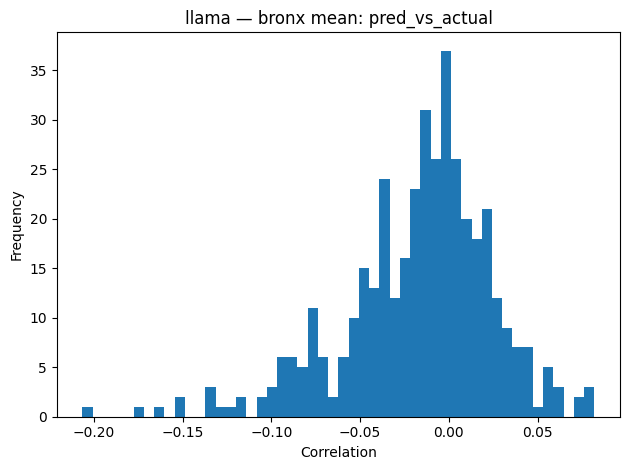

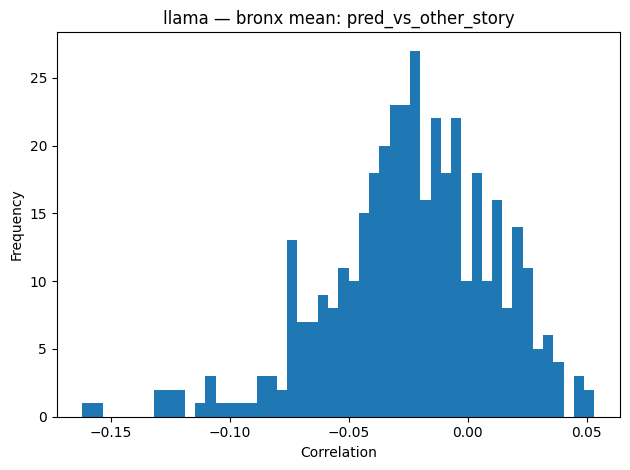

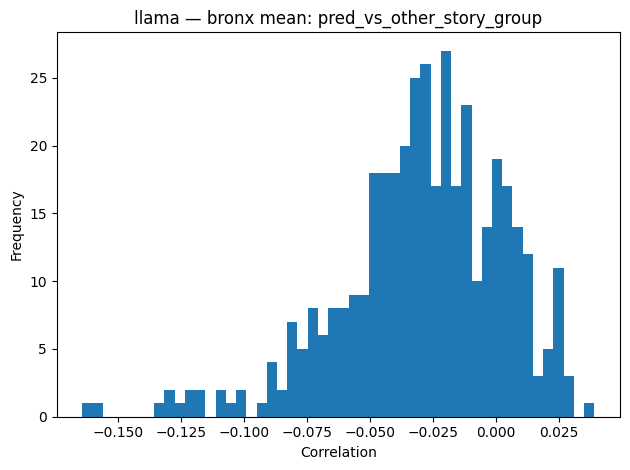


Processing model: llama3
✔ Parcel average saved: /home/y-sato/venv/kenkyu1/analysis_corr/llama3_bronx_parcel_mean_scaled_corr.csv
✔ Subject average saved: /home/y-sato/venv/kenkyu1/analysis_corr/llama3_bronx_subject_mean_corr.csv

=== Mean correlations for this model ===
pred_vs_group: -0.0129
subj_vs_group: 0.2602
pred_vs_actual: -0.0160
pred_vs_other_story: -0.0245
pred_vs_other_story_group: -0.0288


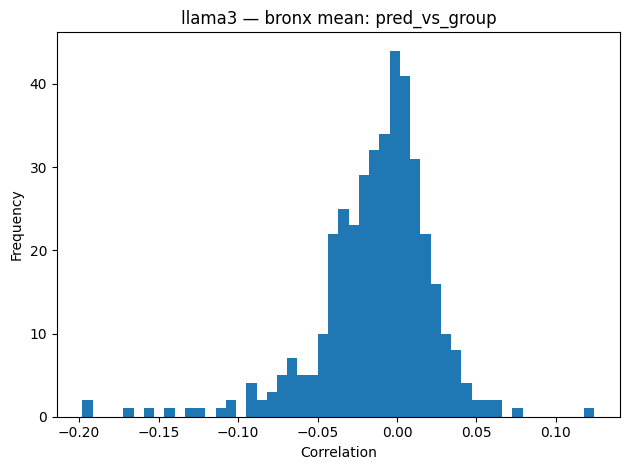

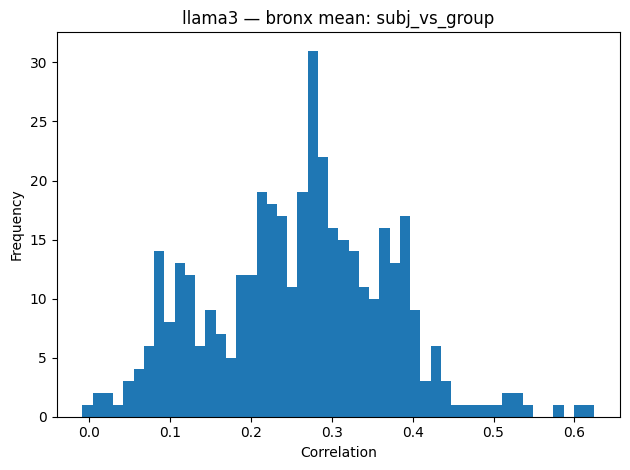

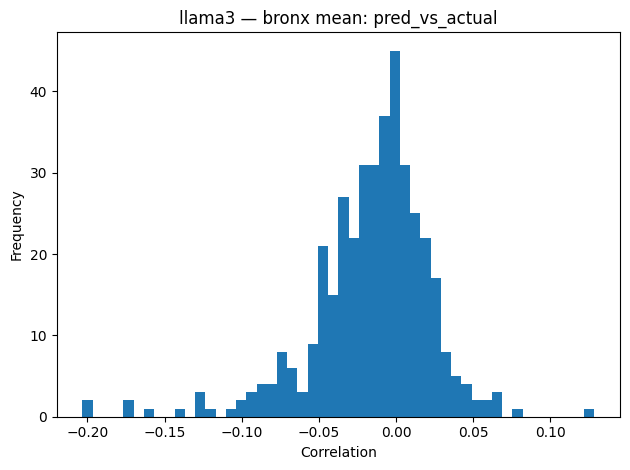

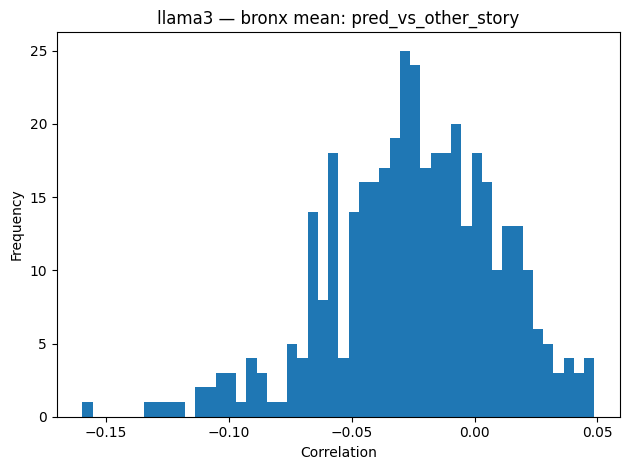

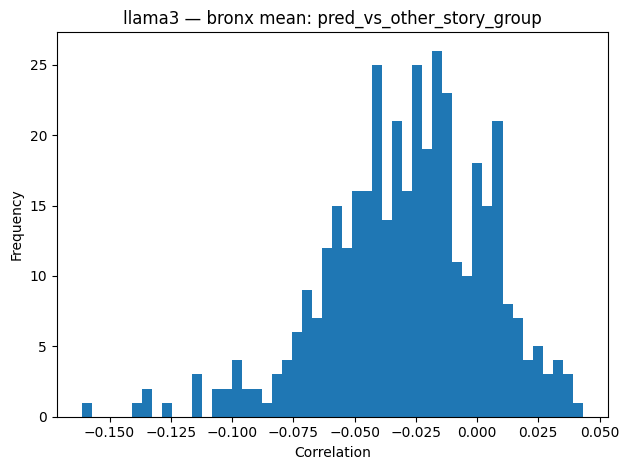


Processing model: gpt2
✔ Parcel average saved: /home/y-sato/venv/kenkyu1/analysis_corr/gpt2_bronx_parcel_mean_scaled_corr.csv
✔ Subject average saved: /home/y-sato/venv/kenkyu1/analysis_corr/gpt2_bronx_subject_mean_corr.csv

=== Mean correlations for this model ===
pred_vs_group: -0.0148
subj_vs_group: 0.2602
pred_vs_actual: -0.0188
pred_vs_other_story: -0.0220
pred_vs_other_story_group: -0.0275


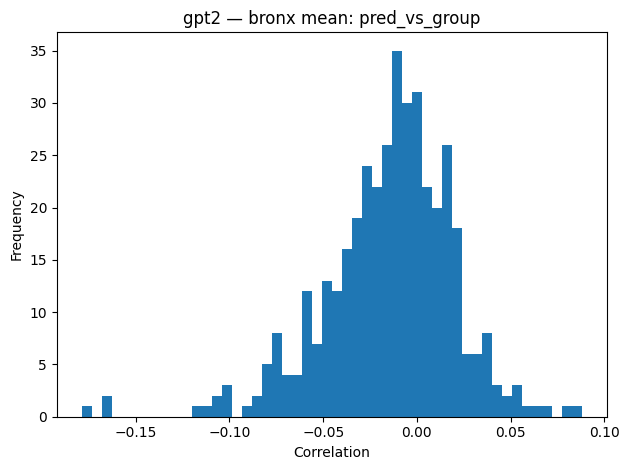

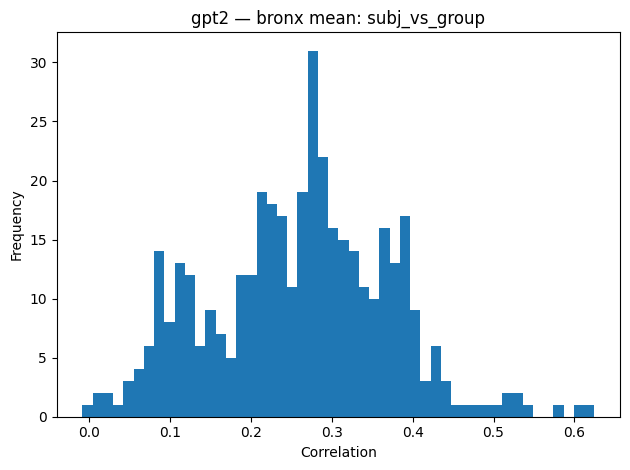

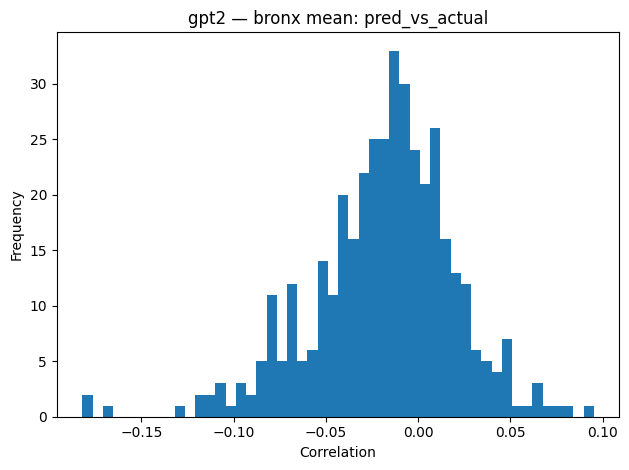

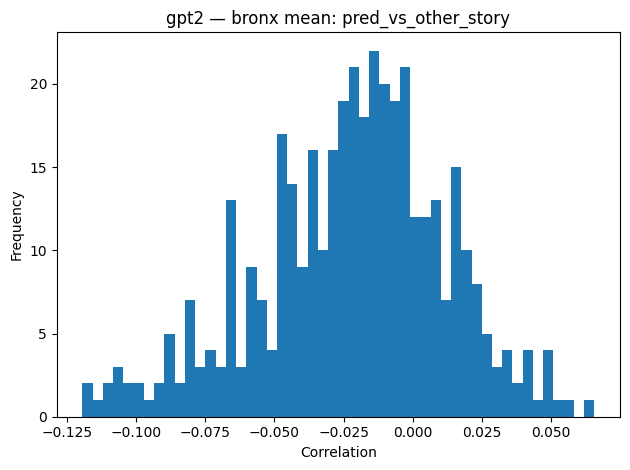

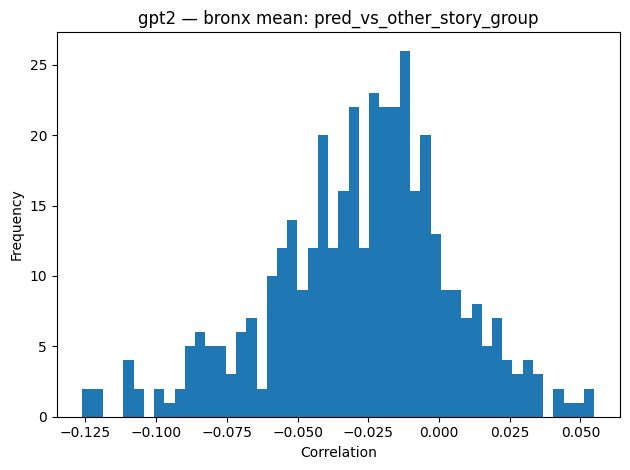


Processing model: gpt_oss
✔ Parcel average saved: /home/y-sato/venv/kenkyu1/analysis_corr/gpt_oss_bronx_parcel_mean_scaled_corr.csv
✔ Subject average saved: /home/y-sato/venv/kenkyu1/analysis_corr/gpt_oss_bronx_subject_mean_corr.csv

=== Mean correlations for this model ===
pred_vs_group: -0.0013
subj_vs_group: 0.2602
pred_vs_actual: -0.0022
pred_vs_other_story: -0.0194
pred_vs_other_story_group: -0.0235


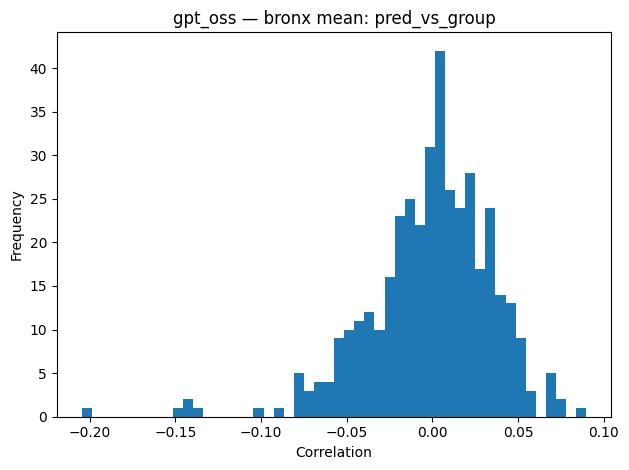

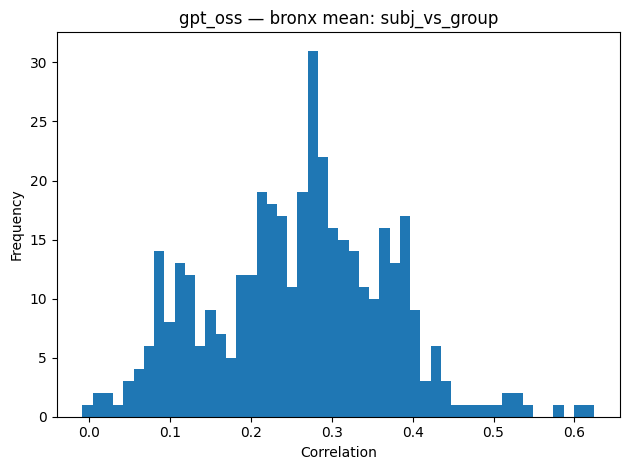

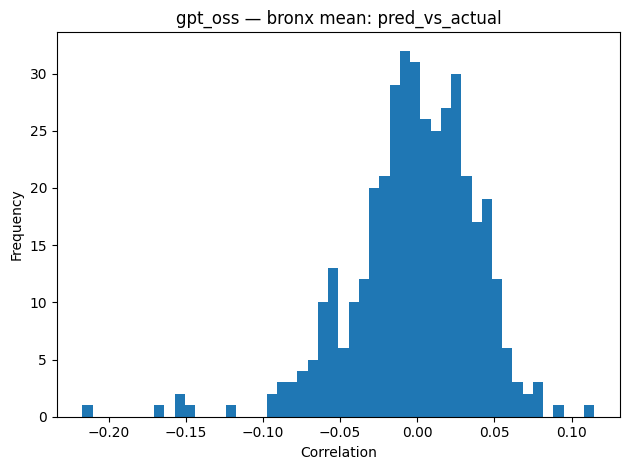

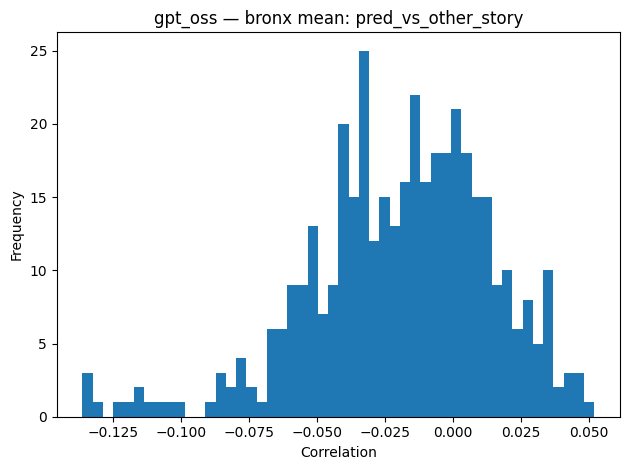

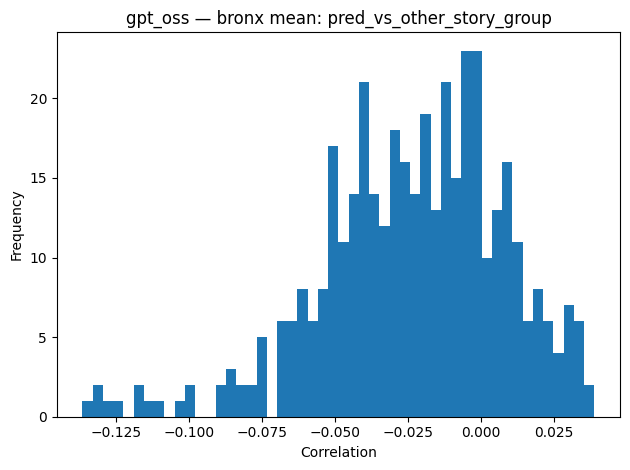


Processing model: gte
✔ Parcel average saved: /home/y-sato/venv/kenkyu1/analysis_corr/gte_bronx_parcel_mean_scaled_corr.csv
✔ Subject average saved: /home/y-sato/venv/kenkyu1/analysis_corr/gte_bronx_subject_mean_corr.csv

=== Mean correlations for this model ===
pred_vs_group: -0.0126
subj_vs_group: 0.2602
pred_vs_actual: -0.0136
pred_vs_other_story: -0.0186
pred_vs_other_story_group: -0.0237


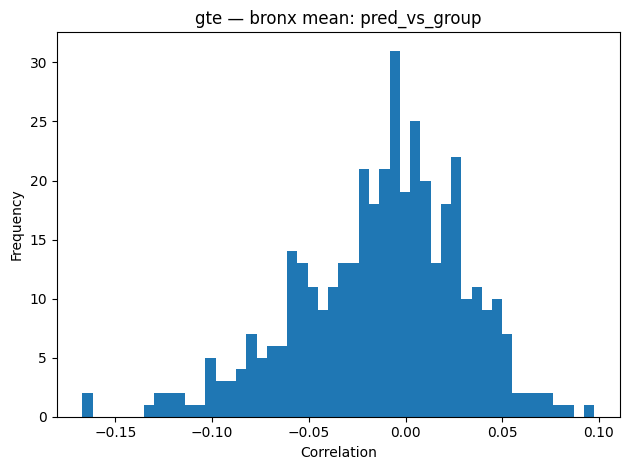

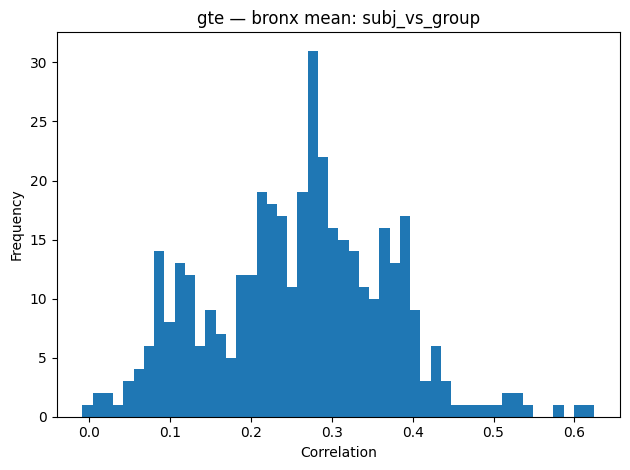

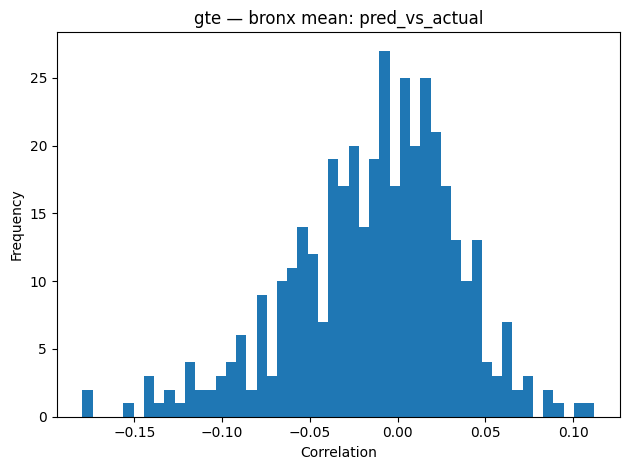

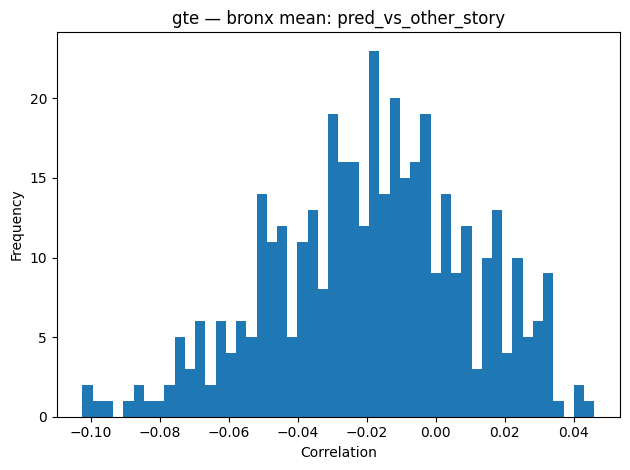

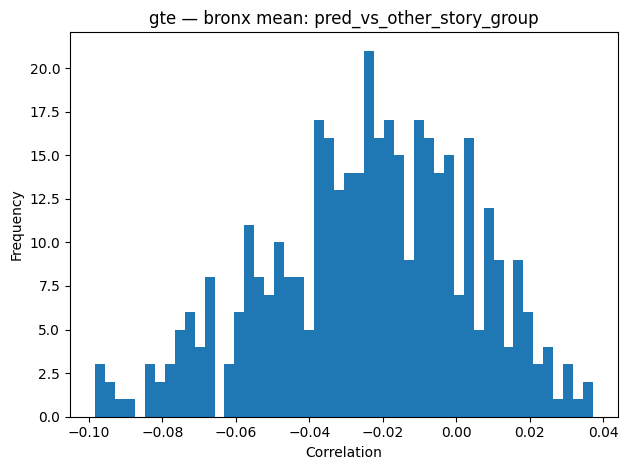


✔ ALL models summary saved: /home/y-sato/venv/kenkyu1/analysis_corr/bronx_ALLMODELS_mean_corr_summary.csv
     model  pred_vs_group  subj_vs_group  pred_vs_actual  pred_vs_other_story  \
0      w2v      -0.002893       0.260171        0.001013            -0.037253   
1    llama      -0.015129       0.260171       -0.017204            -0.023778   
2   llama3      -0.012891       0.260171       -0.015954            -0.024534   
3     gpt2      -0.014837       0.260171       -0.018786            -0.022007   
4  gpt_oss      -0.001348       0.260171       -0.002223            -0.019373   
5      gte      -0.012631       0.260171       -0.013556            -0.018646   

   pred_vs_other_story_group  
0                  -0.040716  
1                  -0.029454  
2                  -0.028835  
3                  -0.027475  
4                  -0.023516  
5                  -0.023703  


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# 一括処理したいモデル一覧
# =====================================================
model_list = ["w2v", "llama", "llama3", "gpt2", "gpt_oss", "gte"]
train_story = "bronx" 
test_story = "piemanpni"

base_dir = "/home/y-sato/venv/kenkyu1/analysis_corr"

# =====================================================
# 結果をまとめるテーブル（後で CSV にする）
# =====================================================
summary_rows = []

# =====================================================
# モデルごとにループ処理
# =====================================================
for model_name in model_list:
    print("\n==========================================")
    print(f"Processing model: {model_name}")
    print("==========================================")

    input_file = f"{base_dir}/{model_name}_{train_story}_allsubjects_with_{test_story}_corr_df.csv"

    # ----------------------
    # ② データ読み込み
    # ----------------------
    df = pd.read_csv(input_file)

    # ----------------------
    # ③ 相関の列（※二乗しない）
    # ----------------------
    corr_cols = [
        "pred_vs_group",
        "subj_vs_group",
        "pred_vs_actual",
        "pred_vs_other_story",
        "pred_vs_other_story_group"
    ]

    df_corr = df[corr_cols].copy()

    # ----------------------
    # ④ Parcel ごとの平均保存（そのまま平均）
    # ----------------------
    df_parcel_mean = (
        df.groupby("parcel")[corr_cols]
        .mean()
        .reset_index()
    )
    parcel_out = f"{base_dir}/{model_name}_{train_story}_parcel_mean_scaled_corr.csv"
    df_parcel_mean.to_csv(parcel_out, index=False, encoding="utf-8-sig")
    print("✔ Parcel average saved:", parcel_out)

    # ----------------------
    # ⑤ Subject ごとの平均保存（そのまま平均）
    # ----------------------
    df_subject_mean = (
        df.groupby("subject")[corr_cols]
        .mean()
        .reset_index()
    )
    subject_out = f"{base_dir}/{model_name}_{train_story}_subject_mean_corr.csv"
    df_subject_mean.to_csv(subject_out, index=False, encoding="utf-8-sig")
    print("✔ Subject average saved:", subject_out)

    # ----------------------
    # ⑥ 全体平均（モデル別の平均値）
    # ----------------------
    print("\n=== Mean correlations for this model ===")
    row = {"model": model_name}

    for col in corr_cols:
        mean_val = df[col].mean()
        row[col] = mean_val
        print(f"{col}: {mean_val:.4f}")

    summary_rows.append(row)

    # ----------------------
    # ⑦ Parcel平均のヒストグラム
    # ----------------------
    df_hist = df_parcel_mean.copy()
    exclude_cols = ["subject", "parcel", "network"]
    plot_cols = [c for c in df_hist.columns if c not in exclude_cols]

    for col in plot_cols:
        plt.figure()
        plt.hist(df_hist[col].dropna(), bins=50)
        plt.title(f"{model_name} — {train_story} mean: {col}")
        plt.xlabel("Correlation")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()


# =====================================================
# ★ 最後に全モデルまとめた CSV を出力
# =====================================================
df_summary = pd.DataFrame(summary_rows)
summary_csv = f"{base_dir}/{train_story}_ALLMODELS_mean_corr_summary.csv"
df_summary.to_csv(summary_csv, index=False, encoding="utf-8-sig")

print("\n==========================================")
print("✔ ALL models summary saved:", summary_csv)
print(df_summary)
print("==========================================")


In [6]:
# =====================================================
# ★ 追加：全モデル比較ヒストグラム（PNG保存 + 凡例改善）
# =====================================================

import matplotlib.pyplot as plt
import numpy as np

# 比較する4つのメトリクス
plot_metrics = [
    "pred_vs_actual",
    "pred_vs_other_story",
    "pred_vs_group",
    "pred_vs_other_story_group"
]

colors = {
    "pred_vs_actual": "tab:blue",
    "pred_vs_other_story": "tab:orange",
    "pred_vs_group": "tab:green",
    "pred_vs_other_story_group": "tab:red",
}

# ================================
# ★ モデル名置き換え
# ================================
rename_map = {
    "llama": "mistral",
    "gte": "e5",
}
df_summary["model_plot"] = df_summary["model"].replace(rename_map)

plt.figure(figsize=(12, 6))

models = df_summary["model_plot"].tolist()
x = np.arange(len(models))
bar_width = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

# 棒グラフの描画
for metric, offset in zip(plot_metrics, offsets):
    plt.bar(
        x + offset * bar_width,
        df_summary[metric],
        width=bar_width,
        color=colors[metric],
        label=metric
    )

plt.xticks(x, models, rotation=45)
plt.ylabel("Mean squared correlation")
plt.title("Mean squared correlations across models")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()

# ★ PNG 保存
save_path = f"../analysis_corr/{train_story}_model_comparison_bars.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"Saved: {save_path}")


Saved: ../analysis_corr/bronx_model_comparison_bars.png
